# 1. Perform PCA for Breast Cancer Dataset (3 points)



You can find this dataset in the scikit-learn library, import it and convert to pandas dataframe. Original labels are ‘0’ and ‘1’; for better readability change these names to: ‘benign’ and ‘malignant’.

In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
import sklearn.datasets as datasets


data = datasets.load_breast_cancer()

df_cancer = pd.DataFrame(data.data, columns=data.feature_names)

df_cancer['target'] = data.target

y = data.target

df_cancer['target'] = df_cancer['target'].map({0: 'malignant', 1: 'benign'})

print(df_cancer.tail())

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
564           0.11590         0.24390              0.13890         0.1726   
565           0.10340         0.14400              0.09791         0.1752   
566           0.10230         0.09251              0.05302         0.1590   
567           0.27700         0.35140              0.15200         0.2397   
568           0.04362         0.00000              0.00000         0.1587   

     mean fractal dimension  ...  worst texture  worst perimeter  wo

Visualize correlations between pairs of features (due to the greater number of features use pandas corr() function instead of pairplot and seaborn heatmap()).


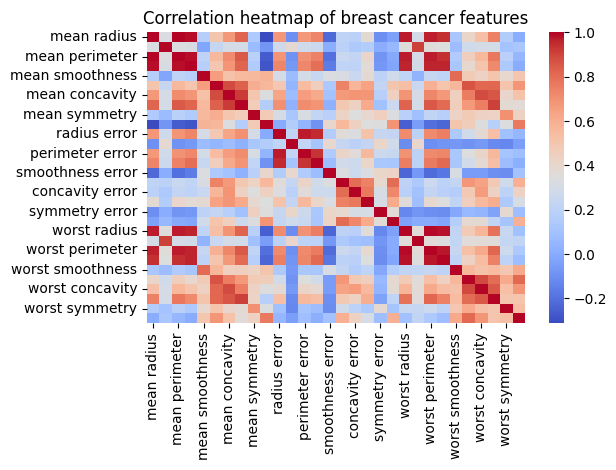

In [10]:
corr_matrix = df_cancer.drop(columns=['target']).corr()


sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation heatmap of breast cancer features')
plt.tight_layout()
plt.show()


Perform PCA and visualize the data.


In [11]:
x_cancer = df_cancer.drop(columns=['target'])
x_cancer = StandardScaler().fit_transform(x_cancer)

y_cancer = df_cancer['target']

df_cancer_standardized = pd.DataFrame(data = x_cancer, columns=data.feature_names)
df_cancer_standardized['target'] = df_cancer['target']


pca_cancer = PCA(n_components=2)
principal_components_cancer = pca_cancer.fit_transform(x_cancer)

principal_df_cancer = pd.DataFrame(data=principal_components_cancer, columns=['Principal Component 1', 'Principal Component 2'])

final_df_cancer = pd.concat([principal_df_cancer, df_cancer['target']], axis=1)
final_df_cancer.head(15)


,Principal Component 1,Principal Component 2,target
0,9.192837,1.948583,malignant
1,2.387802,-3.768172,malignant
2,5.733896,-1.075174,malignant
3,7.122953,10.275589,malignant
4,3.935302,-1.948072,malignant
5,2.380247,3.949929,malignant
6,2.238883,-2.690031,malignant
7,2.143299,2.340244,malignant
8,3.174924,3.391813,malignant
9,6.351747,7.727174,malignant


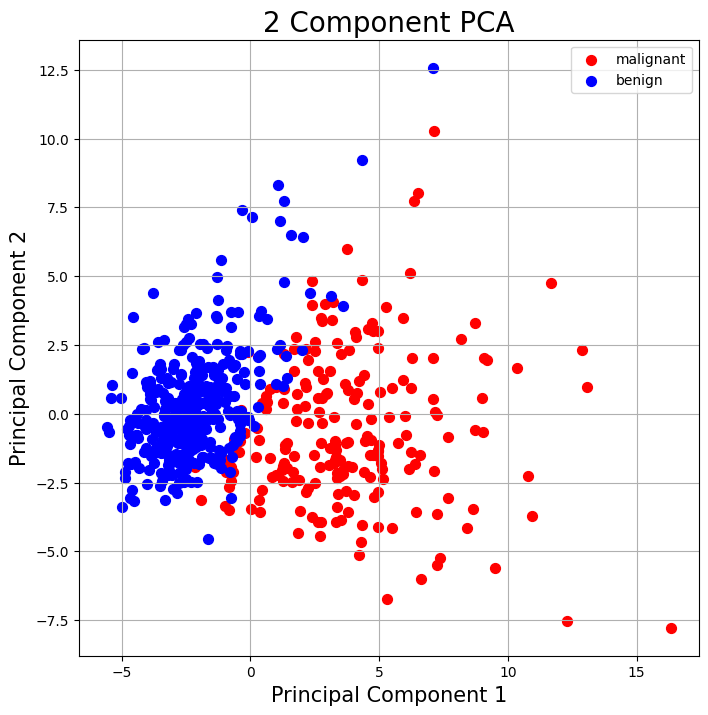

In [12]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 Component PCA', fontsize = 20)

cancer_targets = ['malignant', 'benign']
colors = ['r', 'b']
for target, color in zip(cancer_targets, colors):
    indicesToKeep = final_df_cancer['target'] == target
    ax.scatter(final_df_cancer.loc[indicesToKeep, 'Principal Component 1']
               , final_df_cancer.loc[indicesToKeep, 'Principal Component 2']
               , c = color
               , s = 50)
ax.legend(cancer_targets)
ax.grid()

Examine explained variance, draw a plot showing relation between total explained variance and number of principal components used.



In [13]:
pca_cancer.explained_variance_ratio_


array([0.44272026, 0.18971182])

The first two principal components contain 63.24% of the information. The first principal component contains 44.27% of the variance and the second principal component contains 18.97% of the variance.

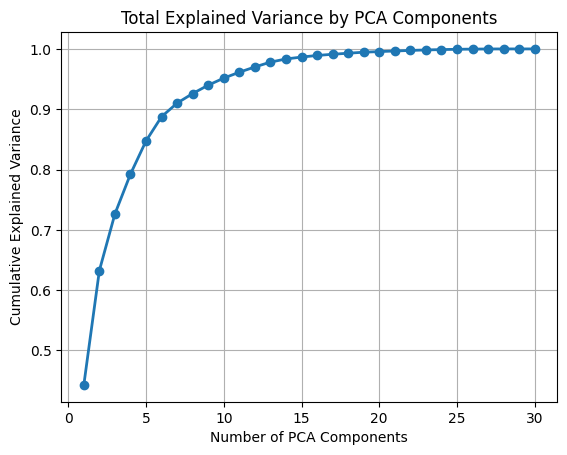

In [14]:
pca_all = PCA()
pca_all.fit(x_cancer)

explained_variance = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.title('Total Explained Variance by PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')

plt.grid()
plt.show()


Use recursive feature elimination (available in scikit-learn module) or another feature ranking algorithm to split 30 features into 15 “more important” and 15 “less important” features. Then repeat the last step from the full data set - draw a plot showing relation between total explained variance and number of principal components used for all 3 cases. Explain the result briefly.



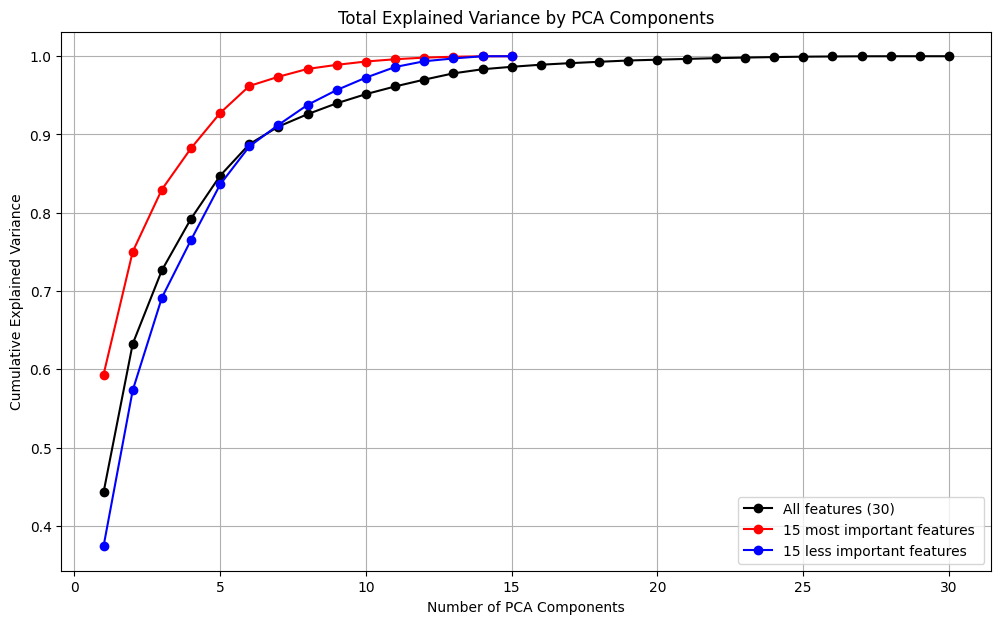

In [15]:
from sklearn.linear_model import LogisticRegression

#RFE (Recursive Feature Elimination)
estimator = LogisticRegression(max_iter=10000)
selector = RFE(estimator, n_features_to_select=15, step=1)
selector.fit(x_cancer, y_cancer)

important_mask = selector.support_
less_important_mask = ~important_mask

X_important = x_cancer[:, important_mask]
X_less_important = x_cancer[:, less_important_mask]

pca_full = PCA().fit(x_cancer)
pca_important = PCA().fit(X_important)
pca_less_important = PCA().fit(X_less_important)

var_full = np.cumsum(pca_full.explained_variance_ratio_)
var_important = np.cumsum(pca_important.explained_variance_ratio_)
var_less_important = np.cumsum(pca_less_important.explained_variance_ratio_)

plt.figure(figsize=(12, 7))
plt.plot(range(1, len(var_full) + 1), var_full, 
         label='All features (30)', marker='o', color='black')
plt.plot(range(1, len(var_important) + 1), var_important, 
         label='15 most important features ', marker='o', color='red')
plt.plot(range(1, len(var_less_important) + 1), var_less_important, 
         label='15 less important features ', marker='o', color='blue')

plt.legend()
plt.title('Total Explained Variance by PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

The curve for the 15 features selected by RFE climbs the fastest - this shows that we only need about 4 of 5 principal components to capture over 90% of the useful information. These selected features are highly informative and strongly correlated so they are easy for PCA to compress.

The curve for the discarded features starts the lowest and grows slower, the data here is less relevant or noisy, so we have to use more components (~7) just to reach that same 90% threshold.

# 2: KernelPCA (3 points)
Visualize in 2D datasets used in this lab, experiment with the parameters of the KernelPCA method change kernel and gamma params.
Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html

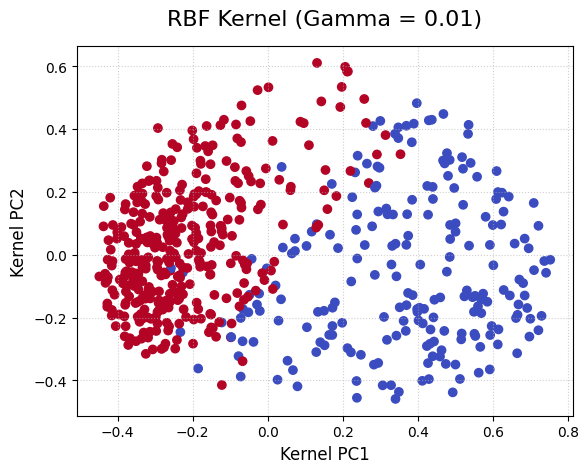

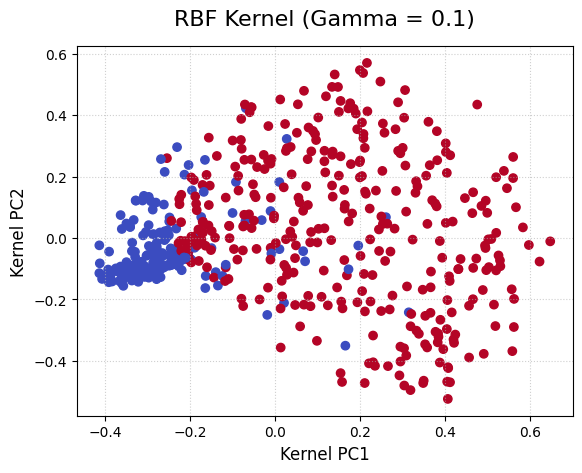

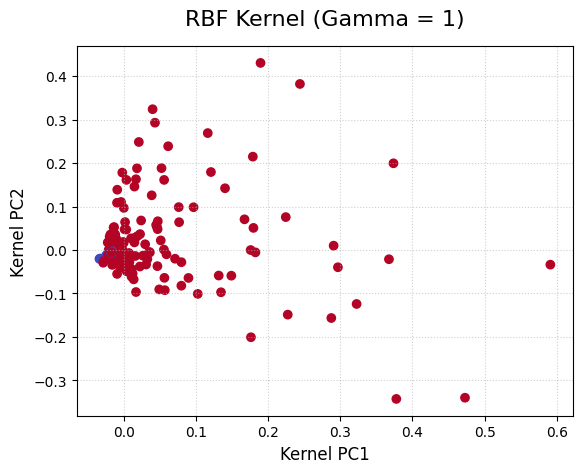

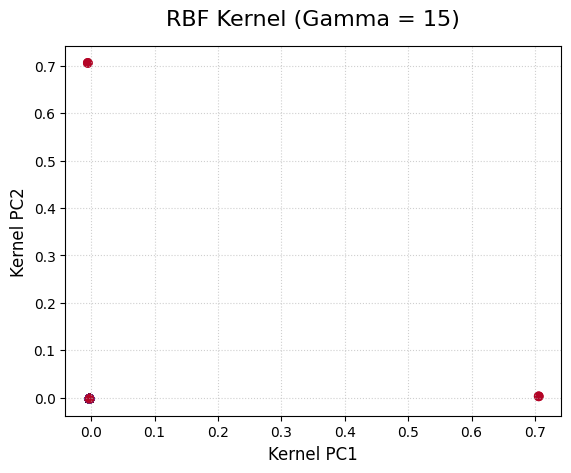

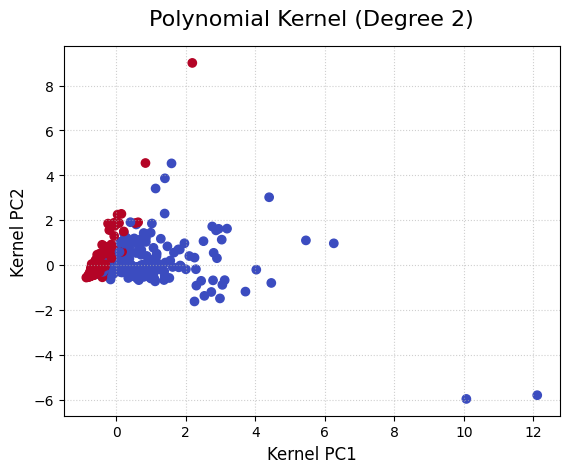

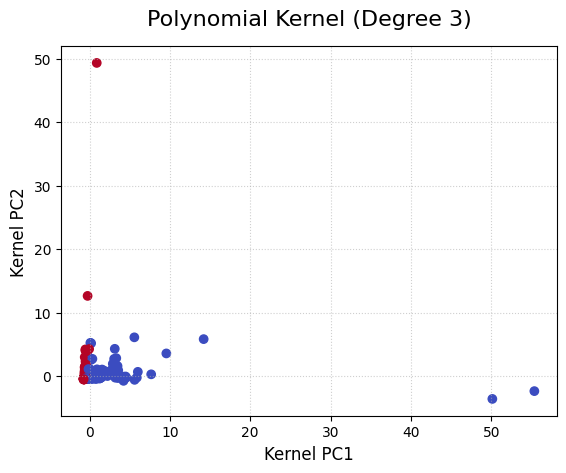

In [17]:
from sklearn.decomposition import KernelPCA

kpca_rbf_low = KernelPCA(n_components=2, kernel='rbf', gamma=0.01)
X_kpca_1 = kpca_rbf_low.fit_transform(x_cancer)

plt.scatter(X_kpca_1[:, 0], X_kpca_1[:, 1], c=y, cmap='coolwarm')
plt.title('RBF Kernel (Gamma = 0.01)', fontsize=16, pad=15)
plt.xlabel("Kernel PC1", fontsize=12)
plt.ylabel("Kernel PC2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()




kpca_rbf_high = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
X_kpca_2 = kpca_rbf_high.fit_transform(x_cancer)

plt.scatter(X_kpca_2[:, 0], X_kpca_2[:, 1], c=y, cmap='coolwarm')
plt.title('RBF Kernel (Gamma = 0.1)', fontsize=16, pad=15)
plt.xlabel("Kernel PC1", fontsize=12)
plt.ylabel("Kernel PC2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


kpca_rbf_high = KernelPCA(n_components=2, kernel='rbf', gamma=1)
X_kpca_2 = kpca_rbf_high.fit_transform(x_cancer)

plt.scatter(X_kpca_2[:, 0], X_kpca_2[:, 1], c=y, cmap='coolwarm')
plt.title('RBF Kernel (Gamma = 1)', fontsize=16, pad=15)
plt.xlabel("Kernel PC1", fontsize=12)
plt.ylabel("Kernel PC2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

kpca_rbf_high = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_kpca_2 = kpca_rbf_high.fit_transform(x_cancer)

plt.scatter(X_kpca_2[:, 0], X_kpca_2[:, 1], c=y, cmap='coolwarm')
plt.title('RBF Kernel (Gamma = 15)', fontsize=16, pad=15)
plt.xlabel("Kernel PC1", fontsize=12)
plt.ylabel("Kernel PC2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=2)
X_kpca_3 = kpca_poly.fit_transform(x_cancer)

plt.scatter(X_kpca_3[:, 0], X_kpca_3[:, 1], c=y, cmap='coolwarm')
plt.title('Polynomial Kernel (Degree 2)', fontsize=16, pad=15)
plt.xlabel("Kernel PC1", fontsize=12)
plt.ylabel("Kernel PC2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show() 

kpca_poly = KernelPCA(n_components=2, kernel='poly', degree=3)
X_kpca_3 = kpca_poly.fit_transform(x_cancer)

plt.scatter(X_kpca_3[:, 0], X_kpca_3[:, 1], c=y, cmap='coolwarm')
plt.title('Polynomial Kernel (Degree 3)', fontsize=16, pad=15)
plt.xlabel("Kernel PC1", fontsize=12)
plt.ylabel("Kernel PC2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 3: Classic PCA Analysis on MNIST (4 points)

Download the MNIST data set (there is a function to load this set in libraries such as scikit-learn, keras). It is a collection of black and white photos of handwritten digits with a resolution of 28x28 pixels, which together gives 784 dimensions.

In [18]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

print(f"Oryginalny kształt X: {X.shape}") # Zobaczysz (70000, 28, 28)


ModuleNotFoundError: No module named 'tensorflow.python'

Try to visualize this dataset using PCA and KernelPCA, don’t expect full separation of the data.


Similar to the exercises, examine explained variance. Draw explained variance vs number of principal Components plot.

Find number of principal components for 99%, 95%, 90%, and 85% of explained variance.

Draw some sample MNIST digits and from PCA of its images transform data back to its original space. Make an inverse transformation for number of components corresponding with explained variance shown above and draw the reconstructed images. The idea of this exercise is to see visually how depending on the number of components some information is lost.

Perform the same reconstruction using KernelPCA (make comparisons for the same components number).

